In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"..\data\processed\utci_analysis.csv"
)

In [2]:
df["time"] = pd.to_datetime(df["time"])

# ERA5 time is UTC → converting to Ahmedabad/India time
df["local_time"] = (
    df["time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["local_time"] = df["local_time"].dt.tz_localize(None)

print(df[["time", "local_time"]].head(10))

                 time          local_time
0 2021-04-01 00:00:00 2021-04-01 05:30:00
1 2021-04-01 01:00:00 2021-04-01 06:30:00
2 2021-04-01 02:00:00 2021-04-01 07:30:00
3 2021-04-01 03:00:00 2021-04-01 08:30:00
4 2021-04-01 04:00:00 2021-04-01 09:30:00
5 2021-04-01 05:00:00 2021-04-01 10:30:00
6 2021-04-01 06:00:00 2021-04-01 11:30:00
7 2021-04-01 07:00:00 2021-04-01 12:30:00
8 2021-04-01 08:00:00 2021-04-01 13:30:00
9 2021-04-01 09:00:00 2021-04-01 14:30:00


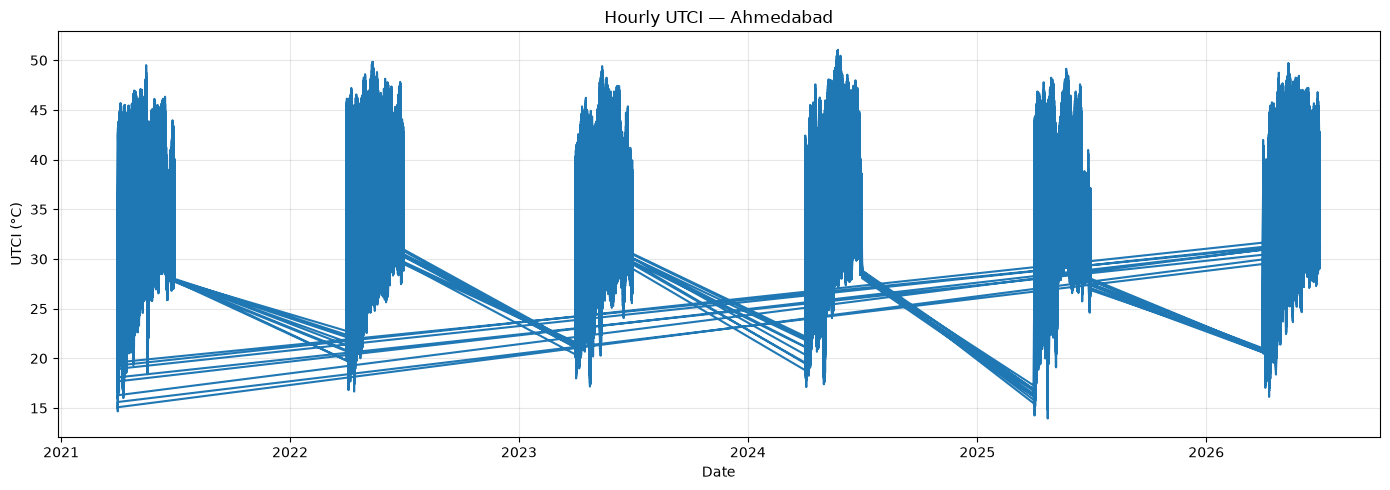

In [3]:
# GRAPH 1 — HOURLY UTCI

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["local_time"],
    df["utci"]
)

plt.xlabel("Date")
plt.ylabel("UTCI (°C)")
plt.title("Hourly UTCI — Ahmedabad")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df["hour"] = df["local_time"].dt.hour

df["period"] = np.where(
    (df["hour"] >= 8) & (df["hour"] < 20),
    "day",
    "night"
)

print(df[["local_time", "hour", "period"]].head(20))

print("\nPeriod counts:")
print(df["period"].value_counts())

            local_time  hour period
0  2021-04-01 05:30:00     5  night
1  2021-04-01 06:30:00     6  night
2  2021-04-01 07:30:00     7  night
3  2021-04-01 08:30:00     8    day
4  2021-04-01 09:30:00     9    day
5  2021-04-01 10:30:00    10    day
6  2021-04-01 11:30:00    11    day
7  2021-04-01 12:30:00    12    day
8  2021-04-01 13:30:00    13    day
9  2021-04-01 14:30:00    14    day
10 2021-04-01 15:30:00    15    day
11 2021-04-01 16:30:00    16    day
12 2021-04-01 17:30:00    17    day
13 2021-04-01 18:30:00    18    day
14 2021-04-01 19:30:00    19    day
15 2021-04-01 20:30:00    20  night
16 2021-04-01 21:30:00    21  night
17 2021-04-01 22:30:00    22  night
18 2021-04-01 23:30:00    23  night
19 2021-04-02 00:30:00     0  night

Period counts:
period
night    58968
day      58968
Name: count, dtype: int64


In [5]:
# --- Nighttime data ---
night_df = df[df["period"] == "night"].copy()

print("Nighttime rows:", len(night_df))

print("\nNighttime UTCI:")
print(night_df["utci"].describe())

print("\nMissing nighttime UTCI:")
print(night_df["utci"].isna().sum())


# --- Nighttime baseline: 90th percentile across full dataset ---
night_utci = df.loc[df["period"] == "night", "utci"]

baseline = night_utci.quantile(0.90)

print(f"\nNighttime 90th-percentile baseline: {baseline:.2f} °C")

Nighttime rows: 58968

Nighttime UTCI:
count    58968.000000
mean        27.987696
std          3.656418
min         13.948167
25%         25.556031
50%         28.651145
75%         30.656263
max         38.099410
Name: utci, dtype: float64

Missing nighttime UTCI:
0

Nighttime 90th-percentile baseline: 32.20 °C


In [6]:
def assign_night_date(local_time):
    hour = local_time.hour

    if 0 <= hour < 8:
        return (local_time - pd.Timedelta(days=1)).date()

    elif 20 <= hour < 24:
        return local_time.date()

    # 08:00–19:59 is daytime
    else:
        return None

In [7]:
night_df["night_date"] = (
    night_df["local_time"]
    .apply(assign_night_date)
)

night_df = night_df.dropna(subset=["night_date"]).copy()

night_df["night_date"] = pd.to_datetime(
    night_df["night_date"]
)

# Keep only April, May, June nights
night_df = night_df[
    night_df["night_date"].dt.month.isin([4, 5, 6])
].copy()

# Nightly mean UTCI — for inspection/reporting only
night_daily = (
    night_df
    .groupby("night_date")["utci"]
    .mean()
    .reset_index()
    .rename(columns={
        "night_date": "date",
        "utci": "nighttime_utci_mean"
    })
)

night_daily["date"] = pd.to_datetime(
    night_daily["date"]
)

print(night_daily.head())
print(night_daily.shape)
print(night_daily["nighttime_utci_mean"].describe())

        date  nighttime_utci_mean
0 2021-04-01            21.034108
1 2021-04-02            21.342038
2 2021-04-03            23.030064
3 2021-04-04            24.140872
4 2021-04-05            23.593723
(546, 2)
count    546.000000
mean      28.012762
std        3.091389
min       18.653517
25%       25.507795
50%       29.073175
75%       30.432937
max       33.166046
Name: nighttime_utci_mean, dtype: float64


In [8]:
night_daily["year"] = night_daily["date"].dt.year
night_daily["month"] = night_daily["date"].dt.month

print(
    night_daily.groupby("year")["date"]
    .agg(["min", "max", "count"])
)

            min        max  count
year                             
2021 2021-04-01 2021-06-30     91
2022 2022-04-01 2022-06-30     91
2023 2023-04-01 2023-06-30     91
2024 2024-04-01 2024-06-30     91
2025 2025-04-01 2025-06-30     91
2026 2026-04-01 2026-06-30     91


In [9]:
print(
    night_daily.groupby(["year", "month"])
    .size()
    .unstack(fill_value=0)
)

month   4   5   6
year             
2021   30  31  30
2022   30  31  30
2023   30  31  30
2024   30  31  30
2025   30  31  30
2026   30  31  30


In [10]:
night_df["nighttime_excess"] = (
    night_df["utci"] - baseline
).clip(lower=0.0)

nctl_df = (
    night_df
    .groupby("night_date")
    .agg(
        NCTL=("nighttime_excess", "sum"),
        nighttime_utci_mean=("utci", "mean"),
        nighttime_hours=("utci", "count")
    )
    .reset_index()
    .rename(columns={
        "night_date": "date"
    })
)

nctl_df["date"] = pd.to_datetime(
    nctl_df["date"]
)

nctl_df["year"] = nctl_df["date"].dt.year
nctl_df["month"] = nctl_df["date"].dt.month

print(
    nctl_df[
        [
            "date",
            "NCTL",
            "nighttime_utci_mean",
            "nighttime_hours"
        ]
    ].head(20)
)

         date  NCTL  nighttime_utci_mean  nighttime_hours
0  2021-04-01   0.0            21.034108              108
1  2021-04-02   0.0            21.342038              108
2  2021-04-03   0.0            23.030064              108
3  2021-04-04   0.0            24.140872              108
4  2021-04-05   0.0            23.593723              108
5  2021-04-06   0.0            23.721976              108
6  2021-04-07   0.0            23.877352              108
7  2021-04-08   0.0            21.228935              108
8  2021-04-09   0.0            20.869483              108
9  2021-04-10   0.0            21.294415              108
10 2021-04-11   0.0            22.023081              108
11 2021-04-12   0.0            22.771343              108
12 2021-04-13   0.0            22.551556              108
13 2021-04-14   0.0            22.539386              108
14 2021-04-15   0.0            23.868704              108
15 2021-04-16   0.0            26.696563              108
16 2021-04-17 

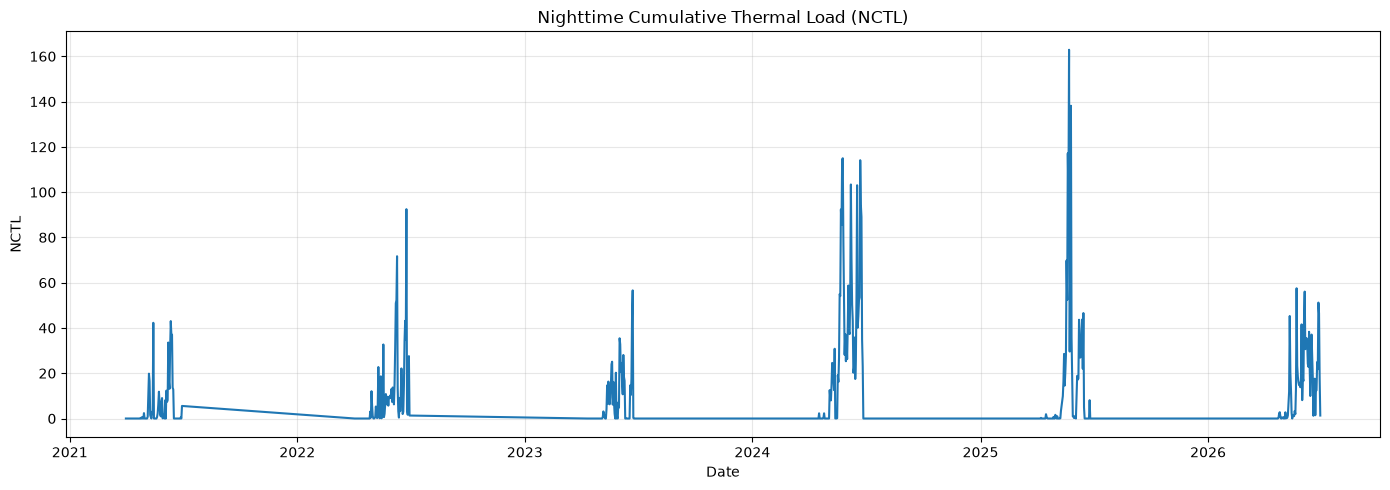

In [11]:
# GRAPH 2 — NCTL

plt.figure(figsize=(14, 5))

plt.plot(
    nctl_df["date"],
    nctl_df["NCTL"]
)

plt.xlabel("Date")
plt.ylabel("NCTL")
plt.title("Nighttime Cumulative Thermal Load (NCTL)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
day_stress = pd.read_csv(
    r"..\data\processed\daystress.csv"
)

day_stress["date"] = pd.to_datetime(day_stress["date"])

nctl_df = nctl_df.copy()

nctl_df["date"] = pd.to_datetime(nctl_df["date"])

nctl_df = nctl_df[
    ["date", "year", "NCTL"]
].copy()


In [13]:
ctbi_df = day_stress.merge(
    nctl_df,
    on="date",
    how="inner"
)

ctbi_df["year"] = ctbi_df["date"].dt.year

ctbi_df = (
    ctbi_df
    .sort_values(["year", "date"])
    .reset_index(drop=True)
)

ctbi_df.head(10)


,date,DayStress,year,NCTL
0,2021-04-01,35.706088,2021,0.0
1,2021-04-02,35.949301,2021,0.0
2,2021-04-03,36.848953,2021,0.0
3,2021-04-04,37.481683,2021,0.0
4,2021-04-05,38.225064,2021,0.0
5,2021-04-06,37.862247,2021,0.0
6,2021-04-07,37.704608,2021,0.0
7,2021-04-08,36.803592,2021,0.0
8,2021-04-09,36.363333,2021,0.0
9,2021-04-10,36.945970,2021,0.0


In [14]:
def minmax_normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )


ctbi_df["DayStress_norm"] = minmax_normalize(
    ctbi_df["DayStress"]
)

ctbi_df["NCTL_norm"] = minmax_normalize(
    ctbi_df["NCTL"]
)

print(
    ctbi_df[
        [
            "date",
            "DayStress",
            "DayStress_norm",
            "NCTL",
            "NCTL_norm"
        ]
    ].head(20)
)

         date  DayStress  DayStress_norm  NCTL  NCTL_norm
0  2021-04-01  35.706088        0.638651   0.0        0.0
1  2021-04-02  35.949301        0.649470   0.0        0.0
2  2021-04-03  36.848953        0.689488   0.0        0.0
3  2021-04-04  37.481683        0.717633   0.0        0.0
4  2021-04-05  38.225064        0.750700   0.0        0.0
5  2021-04-06  37.862247        0.734561   0.0        0.0
6  2021-04-07  37.704608        0.727549   0.0        0.0
7  2021-04-08  36.803592        0.687470   0.0        0.0
8  2021-04-09  36.363333        0.667887   0.0        0.0
9  2021-04-10  36.945970        0.693803   0.0        0.0
10 2021-04-11  37.422226        0.714988   0.0        0.0
11 2021-04-12  38.207856        0.749934   0.0        0.0
12 2021-04-13  36.706528        0.683153   0.0        0.0
13 2021-04-14  36.165317        0.659078   0.0        0.0
14 2021-04-15  37.156787        0.703181   0.0        0.0
15 2021-04-16  37.806788        0.732094   0.0        0.0
16 2021-04-17 

In [15]:
ALPHA = 0.70
BETA = 0.15
GAMMA = 0.15

ctbi_values = []

for year, yearly_data in ctbi_df.groupby("year", sort=True):

    yearly_data = (
        yearly_data
        .sort_values("date")
        .copy()
    )

    previous_ctbi = 0.0

    for _, row in yearly_data.iterrows():

        current_ctbi = (
            ALPHA * previous_ctbi
            + BETA * row["DayStress_norm"]
            + GAMMA * row["NCTL_norm"]
        )

        ctbi_values.append(
            (row["date"], current_ctbi)
        )

        previous_ctbi = current_ctbi


ctbi_values_df = pd.DataFrame(
    ctbi_values,
    columns=["date", "CTBI"]
)

ctbi_df = ctbi_df.merge(
    ctbi_values_df,
    on="date",
    how="left"
)

print(
    ctbi_df[
        [
            "date",
            "DayStress",
            "DayStress_norm",
            "NCTL",
            "NCTL_norm",
            "CTBI"
        ]
    ]
)

          date  DayStress  DayStress_norm       NCTL  NCTL_norm      CTBI
0   2021-04-01  35.706088        0.638651   0.000000   0.000000  0.095798
1   2021-04-02  35.949301        0.649470   0.000000   0.000000  0.164479
2   2021-04-03  36.848953        0.689488   0.000000   0.000000  0.218558
3   2021-04-04  37.481683        0.717633   0.000000   0.000000  0.260636
4   2021-04-05  38.225064        0.750700   0.000000   0.000000  0.295050
..         ...        ...             ...        ...        ...       ...
541 2026-06-26  39.856950        0.823289  21.760080   0.133593  0.454660
542 2026-06-27  40.776587        0.864197  51.200401   0.314338  0.495042
543 2026-06-28  40.257137        0.841090  46.412501   0.284943  0.515434
544 2026-06-29  39.038873        0.786900  17.486601   0.107356  0.494943
545 2026-06-30  37.230830        0.706474   1.310423   0.008045  0.453638

[546 rows x 6 columns]


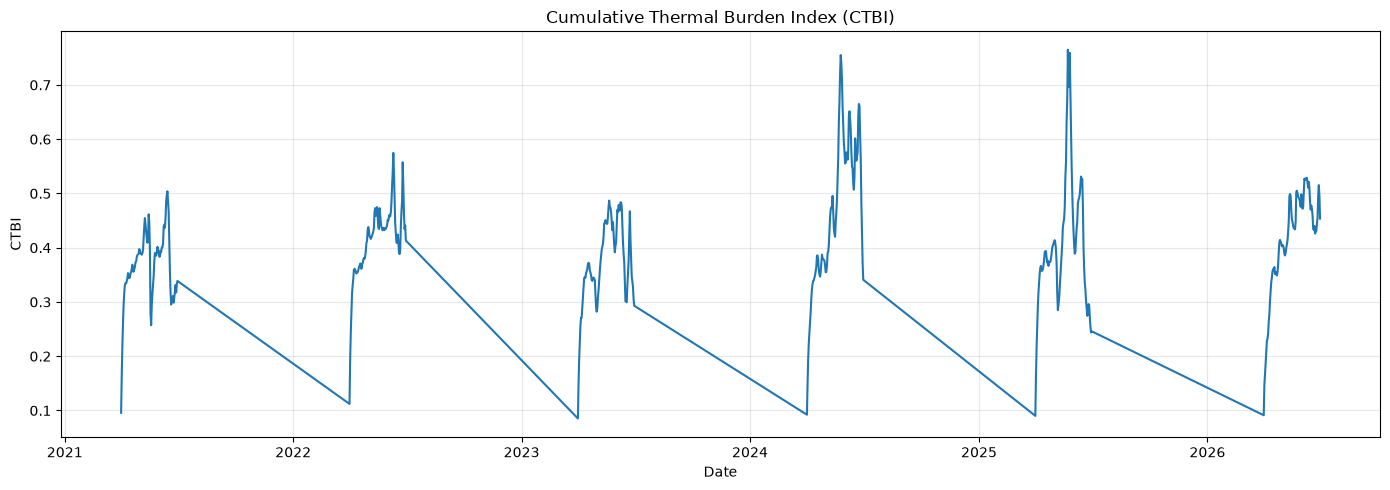

In [16]:
# GRAPH 3 — CTBI

plt.figure(figsize=(14, 5))

plt.plot(
    ctbi_df["date"],
    ctbi_df["CTBI"]
)

plt.xlabel("Date")
plt.ylabel("CTBI")
plt.title("Cumulative Thermal Burden Index (CTBI)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
from pathlib import Path

output_path = Path("../data/processed/CTBI.csv")

ctbi_df.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")
print(f"Rows: {len(ctbi_df):,}")
print(f"Columns: {ctbi_df.columns.tolist()}")

Saved: ..\data\processed\CTBI.csv
Rows: 546
Columns: ['date', 'DayStress', 'year', 'NCTL', 'DayStress_norm', 'NCTL_norm', 'CTBI']
